Histogrmas de pixeles y umbralizacion binaria y binaria inversa

<function matplotlib.pyplot.show(close=None, block=None)>

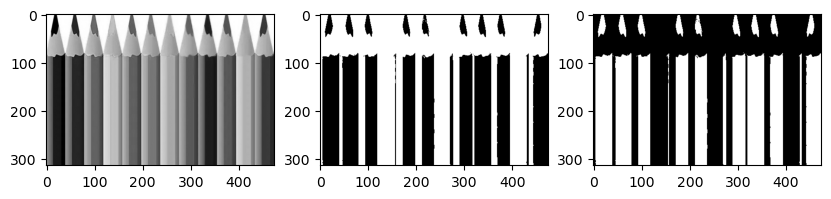

In [6]:
import cv2
import matplotlib.pyplot as plt
imagen=cv2.imread('colores.jpg',0)
#umbralizacion binaria
_,umbral_binario=cv2.threshold(imagen,127,255,cv2.THRESH_BINARY)
_,umbral_binario_inv=cv2.threshold(imagen,127,255,cv2.THRESH_BINARY_INV)
plt.figure(figsize=(10,5))
plt.subplot(1,3,1)
plt.imshow(imagen,cmap='gray')

plt.subplot(1,3,2)
plt.imshow(umbral_binario,cmap='gray')

plt.subplot(1,3,3)
plt.imshow(umbral_binario_inv,cmap='gray')

plt.show


Ejercicio 1

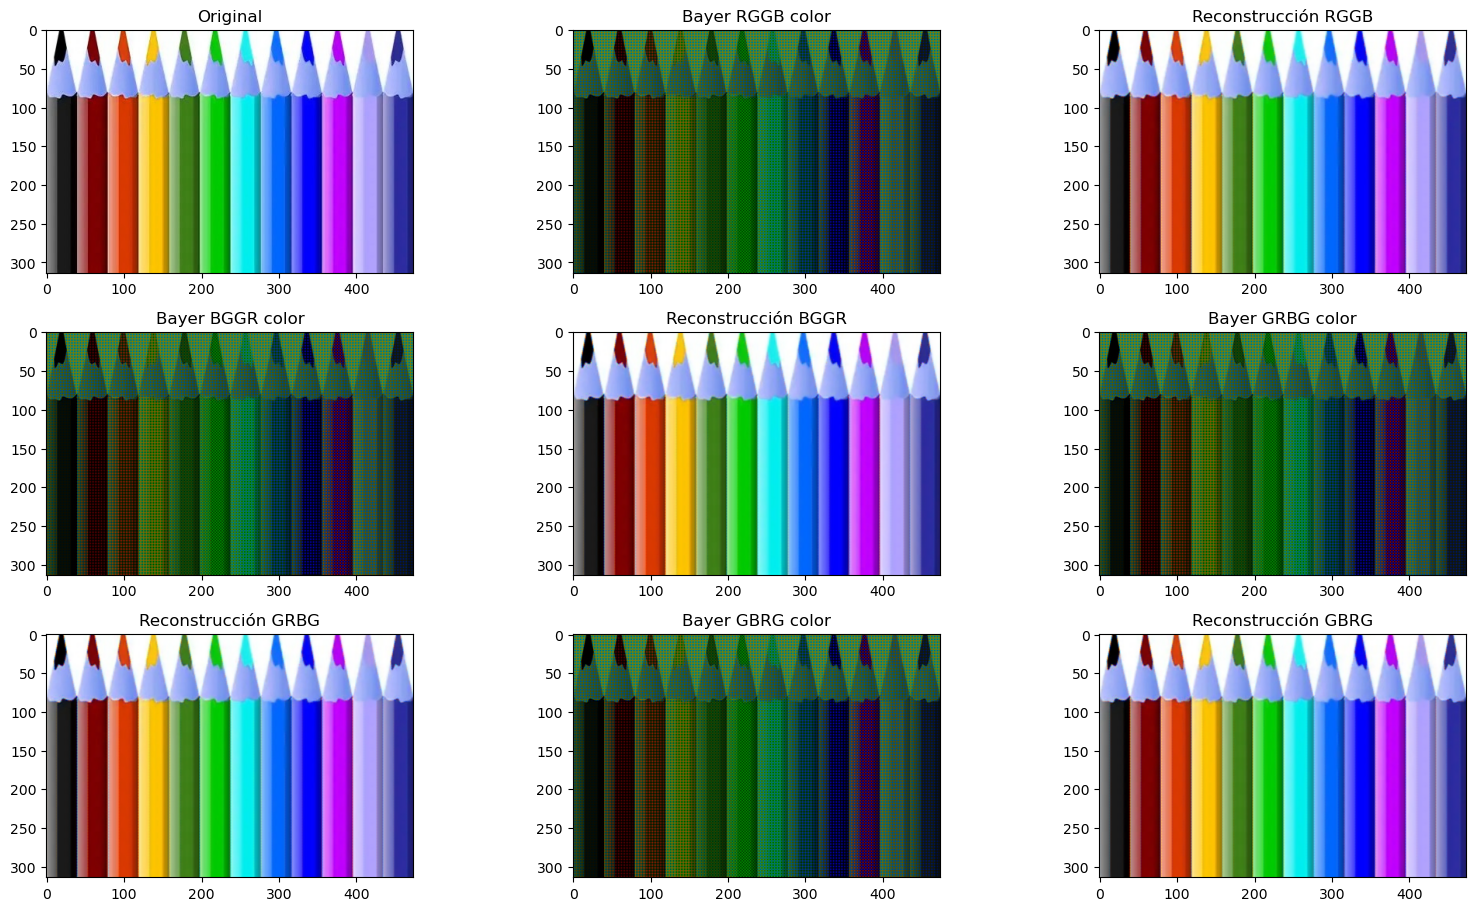

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('colores.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w, _ = img.shape

R = img[:,:,0]
G = img[:,:,1]
B = img[:,:,2]


def bayer_RGGB(R,G,B):
    bayer = np.zeros((h,w,3), dtype=np.uint8)
    bayer[0::2,0::2,0] = R[0::2,0::2]
    bayer[0::2,1::2,1] = G[0::2,1::2]
    bayer[1::2,0::2,1] = G[1::2,0::2]
    bayer[1::2,1::2,2] = B[1::2,1::2]
    return bayer

def bayer_BGGR(R,G,B):
    bayer = np.zeros((h,w,3), dtype=np.uint8)
    bayer[0::2,0::2,2] = B[0::2,0::2]
    bayer[0::2,1::2,1] = G[0::2,1::2]
    bayer[1::2,0::2,1] = G[1::2,0::2]
    bayer[1::2,1::2,0] = R[1::2,1::2]
    return bayer

def bayer_GRBG(R,G,B):
    bayer = np.zeros((h,w,3), dtype=np.uint8)
    bayer[0::2,0::2,1] = G[0::2,0::2]
    bayer[0::2,1::2,0] = R[0::2,1::2]
    bayer[1::2,0::2,2] = B[1::2,0::2]
    bayer[1::2,1::2,1] = G[1::2,1::2]
    return bayer

def bayer_GBRG(R,G,B):
    bayer = np.zeros((h,w,3), dtype=np.uint8)
    bayer[0::2,0::2,1] = G[0::2,0::2]
    bayer[0::2,1::2,2] = B[0::2,1::2]
    bayer[1::2,0::2,0] = R[1::2,0::2]
    bayer[1::2,1::2,1] = G[1::2,1::2]
    return bayer


bayer_rg = bayer_RGGB(R,G,B)
bayer_bg = bayer_BGGR(R,G,B)
bayer_gr = bayer_GRBG(R,G,B)
bayer_gb = bayer_GBRG(R,G,B)


def demosaic_color_fixed(bayer, pattern):
   
    R_chan = bayer[:,:,0]
    G_chan = bayer[:,:,1]
    B_chan = bayer[:,:,2]
   
    rec_R = cv2.cvtColor(R_chan, getattr(cv2,f'COLOR_Bayer{pattern}2BGR'))[:,:,2]
    rec_G = cv2.cvtColor(G_chan, getattr(cv2,f'COLOR_Bayer{pattern}2BGR'))[:,:,1]
    rec_B = cv2.cvtColor(B_chan, getattr(cv2,f'COLOR_Bayer{pattern}2BGR'))[:,:,0]
    
    return np.stack([rec_R, rec_G, rec_B], axis=2)

rec_rg = demosaic_color_fixed(bayer_rg, "RGGB")
rec_bg = demosaic_color_fixed(bayer_bg, "BGGR")
rec_gr = demosaic_color_fixed(bayer_gr, "GRBG")
rec_gb = demosaic_color_fixed(bayer_gb, "GBRG")

plt.figure(figsize=(16,12))

plt.subplot(4,3,1)
plt.imshow(img)
plt.title("Original")

plt.subplot(4,3,2)
plt.imshow(bayer_rg)
plt.title("Bayer RGGB color")
plt.subplot(4,3,3)
plt.imshow(rec_rg)
plt.title("Reconstrucción RGGB")

plt.subplot(4,3,4)
plt.imshow(bayer_bg)
plt.title("Bayer BGGR color")
plt.subplot(4,3,5)
plt.imshow(rec_bg)
plt.title("Reconstrucción BGGR")

plt.subplot(4,3,6)
plt.imshow(bayer_gr)
plt.title("Bayer GRBG color")
plt.subplot(4,3,7)
plt.imshow(rec_gr)
plt.title("Reconstrucción GRBG")

plt.subplot(4,3,8)
plt.imshow(bayer_gb)
plt.title("Bayer GBRG color")
plt.subplot(4,3,9)
plt.imshow(rec_gb)
plt.title("Reconstrucción GBRG")

plt.tight_layout()
plt.show()

Ejercicio 2

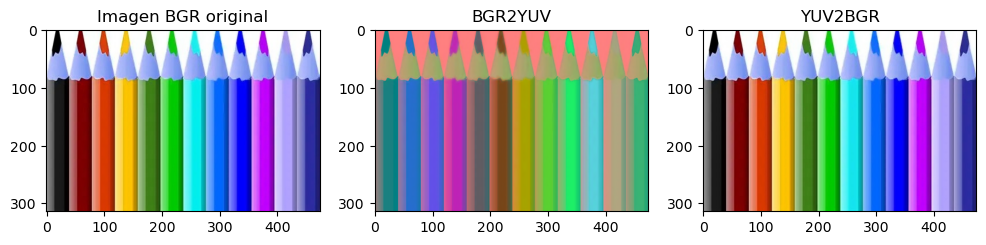

In [9]:
import cv2
import matplotlib.pyplot as plt

imagen_bgr = cv2.imread('colores.jpg')

# BGR -> YUV
imagen_yuv = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2YUV)

# YUV -> BGR
imagen_bgr_recuperada = cv2.cvtColor(imagen_yuv, cv2.COLOR_YUV2BGR)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB))
plt.title('Imagen BGR original')

plt.subplot(1,3,2)
plt.imshow(imagen_yuv)
plt.title('BGR2YUV')

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(imagen_bgr_recuperada, cv2.COLOR_BGR2RGB))
plt.title('YUV2BGR')

plt.show()